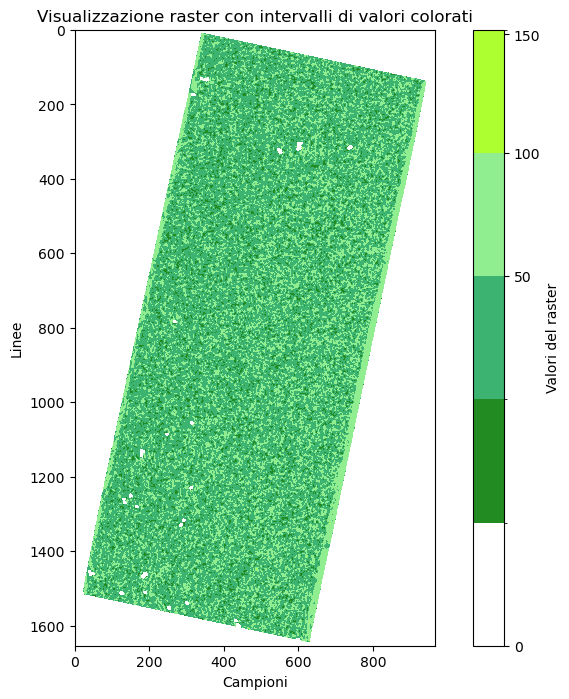

In [31]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Carica il file .tif
tif_path = 'BIO_FP_FH__L2A_20170225T104255_20170303T104322_I_G01_M02_C___T018_F153_01_CT4XKD_FH.tif'  # Modifica con il percorso del tuo file .tif

# Leggi il file raster
with rasterio.open(tif_path) as src:
    # Estrai i dati del raster
    data = src.read(1)  # Legge il primo (e probabilmente unico) band del raster

# Definisci i range di valori
# Supponiamo che tu voglia 3 categorie di valori, ad esempio:
bounds = [0,0.1, 10, 50,100, 152]  # Ranges che vuoi usare, ad esempio 0-50, 50-100, 100-150
green_colors = [
    
    (144/255, 238/255, 144/255, 0.0),  #trasparent
    (34/255, 139/255, 34/255, 1),    # Forest Green
    (60/255, 179/255, 113/255, 1),   # Medium Sea Green
    (144/255, 238/255, 144/255, 1),  # Light Green
   (173/255, 255/255, 47/255, 1)  # Green Yellow,
]

# Crea una mappa di colori personalizzata
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=len(green_colors))

# Crea il grafico
fig, ax = plt.subplots(figsize=(10, 8))

# Visualizza l'immagine, con il colormap personalizzato
cax = ax.imshow(data, cmap=mcolors.ListedColormap(green_colors), norm=norm)

# Aggiungi una barra di colori (colorbar)
cbar = fig.colorbar(cax, ax=ax, boundaries=bounds, ticks=[0, 50, 100, 150])
cbar.set_label('Valori del raster')

# Aggiungi titolo e etichette
plt.title('Visualizzazione raster con intervalli di valori colorati')
plt.xlabel('Campioni')
plt.ylabel('Linee')

# Mostra il grafico
plt.show()